In [222]:

import pandas as pd
import numpy as np
import nflreadpy as nfl
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import poisson
from sklearn.linear_model import PoissonRegressor
from sklearn.model_selection import TimeSeriesSplit
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.model_selection import KFold
from scipy.stats import poisson
from statsmodels.discrete.discrete_model import GeneralizedPoisson # Not gonna use it but its a little better
from sklearn.utils import resample

# I like to have the okabe ito colors, sort of 

from okabeito import lightblue, yellow, orange, green, purple, red, blue, black




In [ ]:
# This pulls data from the nfl read_py library
# We get data on every single play in games from 2006 to 2024


pbp = nfl.load_pbp(list(range(2006, 2024))).to_pandas()


In [255]:
# So frist we are going to make sure we know the id of the quarterback

pbp_pass = pbp.query("passer_id.notnull()").reset_index(drop=True)


# This code will help us calculate game level outcomes

pbp_pass.loc[pbp_pass.pass_touchdown.isnull(), "pass_touchdown"] = 0
pbp_pass.loc[pbp_pass.passer.isnull(),    "passer"]    = "none"


pbp_pass["team_spread"] = np.where(
    pbp_pass["posteam_type"] == "home",
    pbp_pass["spread_line"],
    -pbp_pass["spread_line"]
)

# We create a dataframe with the offensive stats of each quarterback, following Eager

qb_game = (
    pbp_pass
    .groupby(["season","week","passer_id","passer"])
    .agg(pass_td=("pass_touchdown", "sum"),
         n_passes=("pass_touchdown", "count"),
         total_line=("total_line", "mean"),
         spread_line=("team_spread","mean"),
         air_yards=("air_yards","sum"),
         interceptions=("interception","sum"),
         completions=("complete_pass","sum"),
         passing_yards=("passing_yards","sum"),
         posteam_type=("posteam_type", "first"),
        season_type=("season_type", "first"))
    .reset_index()
    .query("n_passes >= 10")
)



In [252]:
# Here is the description

print(qb_game.groupby("pass_td").size())

pass_td
0.0    2410
1.0    3492
2.0    2571
3.0    1188
4.0     399
5.0      75
6.0      17
7.0       3
dtype: int64


In [256]:
# Now we are going to create our feature matrix. The basic idea is for each passer and each game they appear in, we are going to compute
# their statistics on the games that occurred in that season before the game in the dataset. These will be the qb skill features used to
# estimate the passing TDs


rows = []
for season_idx in range(2006, 2024):
    for week_idx in range(1, 23):

        # NFL Games are played once a week, so we filter down the dataframe to contain games from the previous season
        # and games from the earlier weeks. We will aggregate on those data for the feature matrix

        mask = (
            (qb_game["season"] == season_idx - 1) |
            ((qb_game["season"] == season_idx) &
            (qb_game["week"] < week_idx))
        )

        # Now we compute the averages for each

        filtered_qb_game = (
            qb_game.loc[mask]
            .groupby(["passer_id", "passer"])
            .agg(n_games=("pass_td", "count"),
                 pass_td_rate=("pass_td", "mean"),
                 air_yards_pg=("air_yards", "mean"),
                 interceptions_pg=("interceptions", "mean"),
                 completions_pg=("completions", "mean"),
                 passing_yards_pg=("passing_yards", "mean"))
            .reset_index()
            .assign(season=season_idx, week=week_idx))
        rows.append(filtered_qb_game)

# We put all these rows together

x_feat = pd.concat(rows, ignore_index=True)


# We merge with the overall original data frame to pull in some extra context. We also throw away older info

rolling_features_df = (
    qb_game.query("season >= 2007")
    .merge(x_feat, on=["season", "week", "passer_id", "passer"], how="inner")
    .sort_values(["season", "week", "passer_id"])
    .reset_index(drop=True)
)


# These are binary variables so just recoding them as numbers

rolling_features_df["is_home"] = (rolling_features_df["posteam_type"] == "home").astype(int)
rolling_features_df["is_playoff"] = (rolling_features_df["season_type"] == "POST").astype(int)


# Take a look at the data


rolling_features_df[["season","week","passer","pass_td","pass_td_rate","total_line","air_yards_pg","interceptions_pg",
    "completions_pg","passing_yards_pg","n_games"]].head(10)

,season,week,passer,pass_td,pass_td_rate,total_line,air_yards_pg,interceptions_pg,completions_pg,passing_yards_pg,n_games
0,2007,1,J.Delhomme,3.0,1.307692,43.0,263.384615,0.846154,20.230769,215.769231,13
1,2007,1,B.Favre,0.0,1.125000,41.5,331.562500,1.125000,21.437500,242.812500,16
2,2007,1,J.Garcia,0.0,1.500000,40.5,274.125000,0.250000,18.375000,209.125000,8
3,2007,1,T.Green,1.0,0.888889,34.0,199.555556,1.222222,15.000000,161.000000,9
4,2007,1,M.Hasselbeck,1.0,1.500000,40.5,320.357143,1.285714,17.571429,205.500000,14
5,2007,1,D.Huard,0.0,1.222222,37.5,213.333333,0.111111,16.222222,202.666667,9
6,2007,1,J.Kitna,3.0,1.312500,39.5,315.000000,1.375000,23.250000,263.000000,16
7,2007,1,P.Manning,3.0,1.700000,52.5,343.100000,0.800000,22.950000,271.550000,20
8,2007,1,D.McNabb,1.0,1.700000,41.5,279.200000,0.600000,18.000000,261.200000,10
9,2007,1,S.McNair,0.0,1.066667,39.5,240.800000,0.866667,20.733333,214.600000,15


In [242]:
x_feat

,passer_id,passer,n_games,pass_td_rate,air_yards_pg,interceptions_pg,completions_pg,passing_yards_pg,season,week
0,00-0000865,C.Batch,1,3.000000,233.000000,0.000000,15.000000,209.000000,2006,2
1,00-0001361,D.Bledsoe,1,1.000000,304.000000,3.000000,16.000000,246.000000,2006,2
2,00-0001823,A.Brooks,1,0.000000,144.000000,0.000000,6.000000,68.000000,2006,2
3,00-0002110,M.Brunell,1,0.000000,174.000000,0.000000,17.000000,163.000000,2006,2
4,00-0003292,K.Collins,1,0.000000,291.000000,2.000000,17.000000,223.000000,2006,2
...,...,...,...,...,...,...,...,...,...,...
28705,00-0038598,J.Hall,1,0.000000,113.000000,1.000000,5.000000,67.000000,2023,22
28706,00-0039150,B.Young,16,0.687500,250.562500,0.625000,19.687500,179.812500,2023,22
28707,00-0039152,W.Levis,8,1.000000,322.750000,0.500000,18.375000,224.000000,2023,22
28708,00-0039163,C.Stroud,17,1.529412,288.882353,0.294118,20.823529,268.058824,2023,22


In [257]:
# Get the target variable and extract the features we want to use
# We could in theory use pipelines but the data is clean and Poisson regression
# doesn't require preprocessing, and we don't have complex categorical features

# This is the very basic model from the Eager book

X_base = rolling_features_df[["pass_td_rate", "total_line"]].values
y = rolling_features_df["pass_td"].values



model_simple_full = PoissonRegressor(alpha=0, max_iter=1000)
model_simple_full.fit(X_base, y)

print(model_simple_full.coef_)

[0.30939192 0.02309926]


In [245]:
y

array([3., 0., 0., ..., 1., 2., 1.], shape=(9281,))

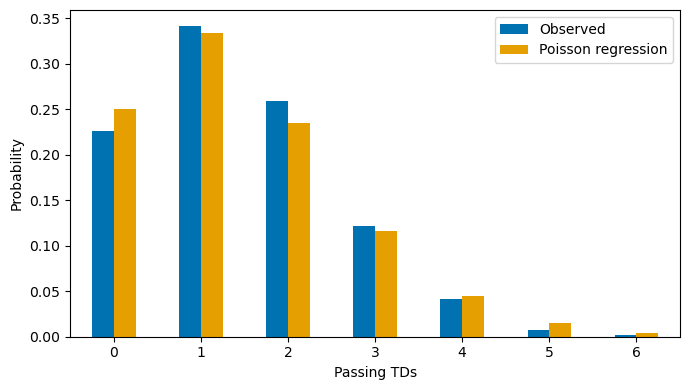

In [244]:
td_counts = np.arange(7)
mu_hat = model_simple_full.predict(X_base)
model_probs = np.column_stack([poisson.pmf(k, mu_hat) for k in td_counts])
model_marginal = model_probs.mean(axis=0)
obs_p = pd.Series(y).value_counts(normalize=True).sort_index()

pd.DataFrame({
    "Observed": [obs_p.get(k, 0) for k in td_counts],
    "Poisson regression": model_marginal,
}, index=td_counts).plot.bar(color=[blue, orange], figsize=(7, 4))

plt.xlabel("Passing TDs")
plt.ylabel("Probability")
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

In [158]:
# Here is very basic cross validation for this model

kf_random = KFold(n_splits=5, shuffle=True, random_state=65)


pw_all = []

for tr, te in kf_random.split(X_base):

    model_basic = PoissonRegressor(alpha=0, max_iter=1000)
    model_basic.fit(X_base[tr], y[tr])
    mu_hat = model_basic.predict(X_base[te])
    score = poisson.logpmf(y[te], mu_hat)
    pw_all.append(score)

 
pw_all = np.concatenate(pw_all)

pw_all.mean()

np.float64(-1.4544564601835692)

In [96]:
rolling_features_df

,season,week,passer_id,passer,pass_td,n_passes,total_line,spread_line,air_yards,interceptions,...,season_type,defteam,n_games,pass_td_rate,air_yards_pg,interceptions_pg,completions_pg,passing_yards_pg,is_home,is_playoff
0,2000,1,00-0000722,T.Banks,1.0,33,37.0,-2.5,0.0,0.0,...,REG,PIT,11,1.545455,0.000000,0.727273,15.363636,194.181818,0,0
1,2000,1,00-0001218,S.Beuerlein,1.0,36,47.5,10.5,0.0,0.0,...,REG,WAS,16,2.250000,0.000000,0.937500,21.437500,277.250000,0,0
2,2000,1,00-0001335,J.Blake,0.0,45,40.5,0.0,0.0,1.0,...,REG,DET,13,1.153846,0.000000,0.923077,16.153846,201.384615,1,0
3,2000,1,00-0001361,D.Bledsoe,1.0,50,36.0,-3.0,0.0,0.0,...,REG,TB,16,1.187500,0.000000,1.312500,19.062500,249.062500,1,0
4,2000,1,00-0002110,M.Brunell,1.0,38,38.5,-10.5,0.0,0.0,...,REG,CLE,17,1.000000,0.000000,0.647059,16.647059,199.470588,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13065,2023,21,00-0033873,P.Mahomes,1.0,50,44.0,4.5,233.0,0.0,...,POST,BAL,38,2.052632,254.368421,0.684211,24.947368,279.289474,0,1
13066,2023,21,00-0034796,L.Jackson,1.0,47,44.0,4.5,344.0,1.0,...,POST,KC,28,1.535714,240.857143,0.500000,18.678571,216.464286,1,1
13067,2023,21,00-0037834,B.Purdy,1.0,36,52.5,7.5,283.0,1.0,...,POST,DET,26,1.846154,218.884615,0.576923,18.538462,248.153846,1,1
13068,2023,22,00-0033873,P.Mahomes,2.0,55,47.0,-1.5,280.0,1.0,...,POST,SF,39,2.025641,253.820513,0.666667,25.076923,278.307692,1,1


In [258]:
feature_sets = {
    "Basic":  ["pass_td_rate","total_line"],
    "Betting Only": ["total_line","spread_line"],
    "Throwing Focus":  ["pass_td_rate", "completions_pg","air_yards_pg","passing_yards_pg","interceptions_pg"],
    "Situation Focused":  ["total_line", "spread_line", "is_home","is_playoff","n_games","week"],
    "Everything": ["pass_td_rate", "total_line", "completions_pg","air_yards_pg","passing_yards_pg","interceptions_pg","spread_line", "is_home","is_playoff","n_games","week"],
    "My Best Idea": ["pass_td_rate","total_line","spread_line","is_home","air_yards_pg","completions_pg","passing_yards_pg"]
}

# Empty dict to store the results
cv_results = {}

kf_random = KFold(n_splits=10, shuffle=True, random_state=65)


for name, cols in feature_sets.items():
    Xm = rolling_features_df[cols].values # So we pull out the features of the matrix we want
    pw_all = [] # Reset out pointwise score
    for tr, te in kf_random.split(Xm):
        model = PoissonRegressor(alpha=0, max_iter=10000)
        model.fit(Xm[tr], y[tr]) # Fit on the training fold
        yhat = model.predict(Xm[te]) # Get test set predictions
        ll = poisson.logpmf(y[te], yhat) 
        pw_all.append(ll) # Add our pointwise score

    pw_all = np.concatenate(pw_all) # Turn the list into an array
    cv_results[name] = dict(
        mean_ll=pw_all.mean(), # Mean Score
        se_ll=np.std(pw_all, ddof=1) / np.sqrt(len(pw_all)), # Standard error
    )

cv_results_df = pd.DataFrame(cv_results).T
cv_results_df.index.name = "model"

In [259]:
cv_results_df

,mean_ll,se_ll
model,,
Basic,-1.454445,0.005925
Betting Only,-1.450535,0.005864
Throwing Focus,-1.455796,0.005962
Situation Focused,-1.446063,0.005897
Everything,-1.441884,0.005885
My Best Idea,-1.443056,0.005864


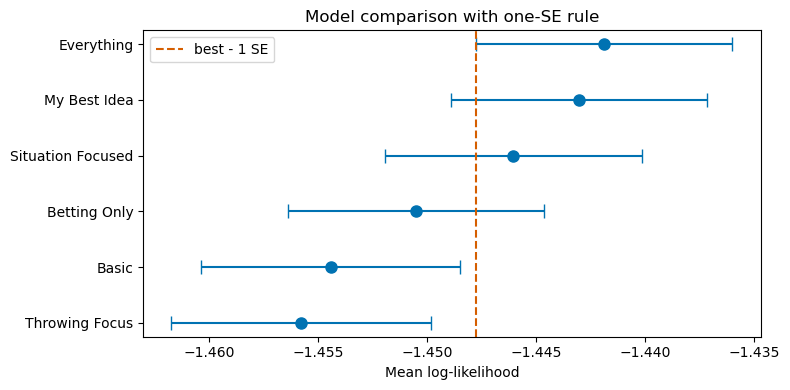

In [260]:
df_sorted = cv_results_df.sort_values("mean_ll", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
y_pos = range(len(df_sorted))

ax.errorbar(df_sorted["mean_ll"], y_pos, xerr=df_sorted["se_ll"], fmt="o",
            color=blue, capsize=5, markersize=8, linewidth=1.5)

threshold = df_sorted["mean_ll"].iloc[0] - df_sorted["se_ll"].iloc[0]
ax.axvline(threshold, color=red, ls="--", lw=1.5, label="best - 1 SE")

ax.set_yticks(y_pos)
ax.set_yticklabels(df_sorted.index)
ax.set_xlabel("Mean log-likelihood")
ax.set_title("Model comparison with one-SE rule")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [261]:
def plot_cv_comparison(cv_results):
    df_sorted = cv_results_df.sort_values("mean_ll", ascending=False)

    fig, ax = plt.subplots(figsize=(8, 4))
    y_pos = range(len(df_sorted))

    ax.errorbar(df_sorted["mean_ll"], y_pos, xerr=df_sorted["se_ll"], fmt="o",
                color=blue, capsize=5, markersize=8, linewidth=1.5)

    threshold = df_sorted["mean_ll"].iloc[0] - df_sorted["se_ll"].iloc[0]
    ax.axvline(threshold, color=red, ls="--", lw=1.5, label="best - 1 SE")

    ax.set_yticks(y_pos)
    ax.set_yticklabels(df_sorted.index)
    ax.set_xlabel("Mean log-likelihood")
    ax.set_title("Model comparison with one-SE rule")
    ax.legend()
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

In [262]:
# Can do time series cross validation


tscv = TimeSeriesSplit(n_splits=5)



# Empty dict to store the results
cv_results = {}



for name, cols in feature_sets.items():
    Xm = rolling_features_df[cols].values # So we pull out the features of the matrix we want
    pw_all = [] # Reset out pointwise score
    for tr, te in tscv.split(Xm):
        model = PoissonRegressor(alpha=0, max_iter=10000)
        model.fit(Xm[tr], y[tr]) # Fit on the training fold
        yhat = model.predict(Xm[te]) # Get test set predictions
        ll = poisson.logpmf(y[te], yhat) 
        pw_all.append(ll) # Add our pointwise score

    pw_all = np.concatenate(pw_all) # Turn the list into an array
    cv_results[name] = dict(
        mean_ll=pw_all.mean(), # Mean Score
        se_ll=np.std(pw_all, ddof=1) / np.sqrt(len(pw_all)), # Standard error
    )

cv_results_df = pd.DataFrame(cv_results).T
cv_results_df.index.name = "model"

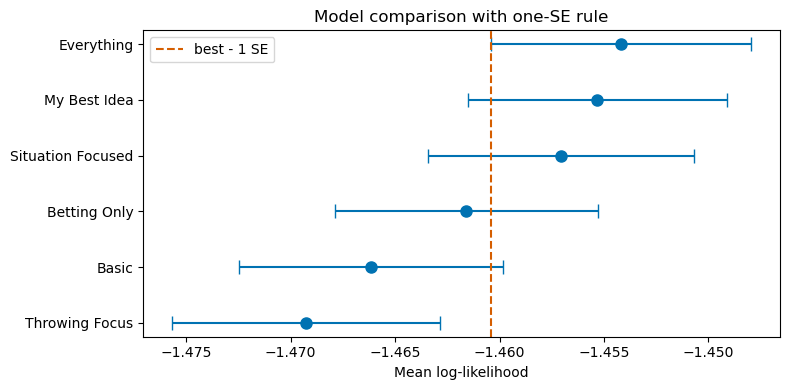

In [263]:
plot_cv_comparison(cv_results)


In [264]:
tscv = TimeSeriesSplit(n_splits=5)
K = 5
cv_results = {}



for name, cols in feature_sets.items():
    Xm = rolling_features_df[cols].values
    
    # full-data fit for bias correction
    full_mod = PoissonRegressor(alpha=0, max_iter=10000)
    full_mod.fit(Xm, y)

    # Mean TD predictions and log-likelihood for the full model
    mu_full = full_mod.predict(Xm)
    L_full = poisson.logpmf(y, mu_full)
    

    
    pw_all = []

    # We are going to use this to store the log likelihood of the models from each fold on the entire dataset
    #
    L_folds = np.zeros((len(y), K))
    

    # Cross validation loop
    for k, (tr, te) in enumerate(tscv.split(Xm)):
        


        model_k = PoissonRegressor(alpha=0, max_iter=10000)
        model_k.fit(Xm[tr], y[tr])
        
        # CV scoring on the test fold
        mu_te = model_k.predict(Xm[te])
        pw_all.append(poisson.logpmf(y[te], mu_te))
        
        # for the bias correction we calculate the likelihood on all the obs
        mu_all = model_k.predict(Xm)
        L_folds[:, k] = poisson.logpmf(y, mu_all)
    
    pw_all = np.concatenate(pw_all)


    # kappa is the correction term for the log-likelihood
    # Basically the average performance improvement of the full model over each of the fold
    # models

    kappa = (L_full - L_folds.mean(axis=1)).mean()
    
    cv_results[name] = dict(
        mean_ll=pw_all.mean(),
        se_ll=np.std(pw_all, ddof=1) / np.sqrt(len(pw_all)),
        corrected_ll=pw_all.mean() + kappa
    )

cv_results_df = pd.DataFrame(cv_results).T
cv_results_df.index.name = "model"

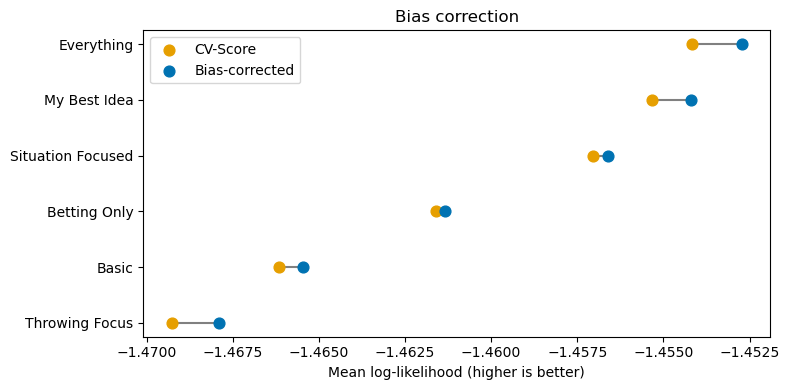

In [265]:
df_sorted = cv_results_df.sort_values("corrected_ll", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
y_pos = range(len(df_sorted))

for i in y_pos:
    ax.plot([df_sorted["mean_ll"].iloc[i], df_sorted["corrected_ll"].iloc[i]],
            [i, i], color="gray", linewidth=1.5, zorder=1)

ax.scatter(df_sorted["mean_ll"], y_pos, color=orange, s=60, zorder=2, label="CV-Score")
ax.scatter(df_sorted["corrected_ll"], y_pos, color=blue, s=60, zorder=2, label="Bias-corrected")

ax.set_yticks(y_pos)
ax.set_yticklabels(df_sorted.index)
ax.set_xlabel("Mean log-likelihood (higher is better)")
ax.set_title("Bias correction")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [268]:
num_boot = 2000
n = len(y)
boot_mus = np.zeros(num_boot)

feature_cols=feature_sets['Basic']
X_base = rolling_features_df[["pass_td_rate", "total_line"]].values

boot_coefs = np.zeros((B, 2))  



X_target = np.array([[1.75,45.59]])

for b in range(num_boot):
    # Two ways to resample, using np.random.choise, or sklearn resample

    #idx = np.random.choice(n, n, replace=True)
    model_boot = PoissonRegressor(alpha=0, max_iter=10000)
    #model_boot.fit(X_base[idx], y[idx])
    
    X_boot, y_boot = resample(X_base, y, n_samples=n, random_state=b)
    model_boot.fit(X_boot, y_boot)
    
    
    boot_mus[b] = model_boot.predict(X_target)[0]
    boot_coefs[b,:] = model_boot.coef_





In [267]:

mu_low, mu_high = np.percentile(boot_mus, [4, 96.0])


print(f"92% interval lambda: [{mu_low:.3f}, {mu_high:.3f}]")
print(f"P(TD>=2) at lo: {1 - poisson.cdf(1, mu_low):.3f}")
print(f"P(TD>=2) at hi: {1 - poisson.cdf(1, mu_high):.3f}")



print(f"\n92% interval Coefficient ")
coef_names = ["pass_td_rate", "total_line"]


for j, name in enumerate(coef_names):
    c_low, c_high = np.percentile(boot_coefs[:, j], [4, 96])
    print(f"  {name:<12} [{c_low:.4f}, {c_high:.4f}]  mean={np.mean(boot_coefs[:, j]):.4f}")


NameError: name 'boot_mus' is not defined